In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [51]:
df15 = pd.read_csv('C:\\Users\\minvy\\Desktop\lavai\\aisdk-2025-05-16.csv')
df15.head()

<>:1: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:1: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\minvy\AppData\Local\Temp\ipykernel_18508\3154163538.py:1: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  df15 = pd.read_csv('C:\\Users\\minvy\\Desktop\lavai\\aisdk-2025-05-16.csv')


,# Timestamp,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,...,Length,Type of position fixing device,Draught,Destination,ETA,Data source type,A,B,C,D
0,16/05/2025 00:00:00,Class A,219023834,54.858782,10.842985,Under way using engine,NaN,13.9,181.0,178.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
1,16/05/2025 00:00:00,Class A,209864000,54.788662,13.978555,Under way using engine,0.0,12.9,170.1,171.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
2,16/05/2025 00:00:00,Class A,209864000,54.788662,13.978555,Under way using engine,0.0,12.9,170.1,171.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
3,16/05/2025 00:00:00,Class A,219244000,56.760775,7.473698,Restricted maneuverability,NaN,0.3,332.4,311.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
4,16/05/2025 00:00:00,Class A,219244000,56.760775,7.473698,Restricted maneuverability,NaN,0.3,332.4,311.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN


In [12]:
df16 = pd.read_csv('aisdk-2025-05-16.csv')
df16.head()

FileNotFoundError: [Errno 2] No such file or directory: 'aisdk-2025-05-16.csv'

In [ ]:
df17 = pd.read_csv('aisdk-2025-05-17.csv')
df17.head()

,# Timestamp,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,...,Length,Type of position fixing device,Draught,Destination,ETA,Data source type,A,B,C,D
0,17/05/2025 00:00:00,Class A,250370000,54.868457,7.389070,Under way using engine,NaN,4.0,274.5,280.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
1,17/05/2025 00:00:00,Class A,219750000,55.097437,14.687435,Under way using engine,0.0,0.0,297.6,190.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
2,17/05/2025 00:00:00,Class A,219000431,54.651750,11.347600,Under way using engine,-11.4,7.9,43.6,42.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
3,17/05/2025 00:00:00,Class A,219002823,56.127015,12.309275,Engaged in fishing,0.0,0.0,101.2,265.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
4,17/05/2025 00:00:00,Base Station,2190064,56.716560,11.519063,Unknown value,NaN,NaN,NaN,NaN,...,NaN,GPS,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN


In [ ]:
df18 = pd.read_csv('aisdk-2025-05-18.csv')
df18.head()

,# Timestamp,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,...,Length,Type of position fixing device,Draught,Destination,ETA,Data source type,A,B,C,D
0,18/05/2025 00:00:00,Base Station,2190064,56.716552,11.519068,Unknown value,NaN,NaN,NaN,NaN,...,NaN,GPS,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
1,18/05/2025 00:00:00,Class A,247415600,54.532227,12.200497,Under way using engine,0.0,13.5,195.7,197.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
2,18/05/2025 00:00:00,Class A,244335000,91.000000,0.000000,Unknown value,NaN,NaN,NaN,NaN,...,115.0,GPS,6.6,DK AAL,17/05/2025 13:00:00,AIS,100.0,15.0,1.0,15.0
3,18/05/2025 00:00:00,Base Station,2194006,55.538870,5.033200,Unknown value,NaN,NaN,NaN,NaN,...,NaN,Surveyed,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
4,18/05/2025 00:00:00,Base Station,2194005,56.344250,4.272000,Unknown value,NaN,NaN,NaN,NaN,...,NaN,Surveyed,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN


In [38]:
df15.columns = (
    df15.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('#', '', regex=False)
)

df15 = df15.drop(columns=['cargo_type'], errors='ignore')

print(df15.columns.tolist())

['_timestamp', 'type_of_mobile', 'mmsi', 'latitude', 'longitude', 'navigational_status', 'rot', 'sog', 'cog', 'heading', 'imo', 'callsign', 'name', 'ship_type', 'width', 'length', 'type_of_position_fixing_device', 'draught', 'destination', 'eta', 'data_source_type', 'a', 'b', 'c', 'd']


In [5]:
print("Forma:", df15.shape)
df15.info()

Forma: (24256059, 25)
<class 'pandas.DataFrame'>
RangeIndex: 24256059 entries, 0 to 24256058
Data columns (total 25 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   _timestamp                      str    
 1   type_of_mobile                  str    
 2   mmsi                            int64  
 3   latitude                        float64
 4   longitude                       float64
 5   navigational_status             str    
 6   rot                             float64
 7   sog                             float64
 8   cog                             float64
 9   heading                         float64
 10  imo                             str    
 11  callsign                        str    
 12  name                            str    
 13  ship_type                       str    
 14  width                           float64
 15  length                          float64
 16  type_of_position_fixing_device  str    
 17  draught       

In [6]:
missing = pd.DataFrame({
    'missing_count': df15.isna().sum(),
    'missing_pct': df15.isna().mean() * 100
}).sort_values('missing_pct', ascending=False)

print(missing)

                                missing_count  missing_pct
eta                                   8850111    36.486187
rot                                   7467767    30.787223
draught                               6554042    27.020226
heading                               5204692    21.457286
cog                                   3356872    13.839313
d                                     2672106    11.016241
c                                     2670457    11.009443
b                                     2649163    10.921655
a                                     2421792     9.984277
width                                 2372482     9.780987
length                                2365780     9.753357
name                                  1874916     7.729681
sog                                   1732541     7.142714
destination                              5287     0.021797
_timestamp                                  0     0.000000
type_of_mobile                              0     0.0000

In [ ]:
# garbage values
for col in ['type_of_mobile', 'ship_type', 'navigational_status',
            'type_of_position_fixing_device', 'destination']:
    if col in df15.columns:
        print(f"\n--- {col} ---")
        print(df15[col].value_counts(dropna=False).head(20))


--- type_of_mobile ---
type_of_mobile
Class A                          21121399
Class B                           1502650
Base Station                      1473449
AtoN                               156687
SAR Airborne                         1846
Search and Rescue Transponder          22
Emergency PIRB                          4
Man Overboard Device                    2
Name: count, dtype: int64

--- ship_type ---
ship_type
Cargo               5535837
Fishing             4426705
Passenger           2909186
Undefined           2438869
Tanker              2120366
Other               1143073
Tug                  838136
Sailing              831960
Pleasure             723565
Pilot                723194
HSC                  593156
SAR                  547275
Dredging             463685
Military             342940
Reserved             129318
Towing               125285
Law enforcement       94014
Towing long/wide      84747
Port tender           62085
Diving                35768
Name: coun

In [40]:
print(df15['type_of_mobile'].value_counts(dropna=False))

pd.crosstab(
    df15['type_of_mobile'],
    df15['sog'].isna(),
    normalize='index'
) * 100

type_of_mobile
Class A                          21121399
Class B                           1502650
Base Station                      1473449
AtoN                               156687
SAR Airborne                         1846
Search and Rescue Transponder          22
Emergency PIRB                          4
Man Overboard Device                    2
Name: count, dtype: int64


sog,False,True
type_of_mobile,,
AtoN,0.000000,100.000000
Base Station,0.000000,100.000000
Class A,99.576458,0.423542
Class B,99.138655,0.861345
Emergency PIRB,100.000000,0.000000
Man Overboard Device,100.000000,0.000000
SAR Airborne,99.837486,0.162514
Search and Rescue Transponder,95.454545,4.545455


type_of_mobile parodo, kas atsiuncia pransesima, cia class A ir class B yra laivai, o kiti, tai visokie pludurai, bazines stotys ir pan. todel issifiltruojam pirma tik laivus, kad turetume bendra ju vaizda

In [41]:
df_ship = df15[df15['type_of_mobile'].isin(['Class A', 'Class B'])].copy()
df_ship.head()

,_timestamp,type_of_mobile,mmsi,latitude,longitude,navigational_status,rot,sog,cog,heading,...,length,type_of_position_fixing_device,draught,destination,eta,data_source_type,a,b,c,d
0,16/05/2025 00:00:00,Class A,219023834,54.858782,10.842985,Under way using engine,NaN,13.9,181.0,178.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
1,16/05/2025 00:00:00,Class A,209864000,54.788662,13.978555,Under way using engine,0.0,12.9,170.1,171.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
2,16/05/2025 00:00:00,Class A,209864000,54.788662,13.978555,Under way using engine,0.0,12.9,170.1,171.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
3,16/05/2025 00:00:00,Class A,219244000,56.760775,7.473698,Restricted maneuverability,NaN,0.3,332.4,311.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
4,16/05/2025 00:00:00,Class A,219244000,56.760775,7.473698,Restricted maneuverability,NaN,0.3,332.4,311.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN


susitvarkom datos formatą 

In [42]:
df_ship = df_ship.rename(columns={'_timestamp': 'timestamp'})

df_ship['timestamp'] = pd.to_datetime(df_ship['timestamp'], dayfirst=True, errors='coerce')

susirusiuojam, kad eitu visa info apie laiva is eiles laike


In [43]:
df_ship = df_ship.sort_values(['mmsi', 'timestamp']).reset_index(drop=True)
df_ship.head()

,timestamp,type_of_mobile,mmsi,latitude,longitude,navigational_status,rot,sog,cog,heading,...,length,type_of_position_fixing_device,draught,destination,eta,data_source_type,a,b,c,d
0,2025-05-16 00:00:04,Class A,3638,55.332243,10.964863,Unknown value,NaN,0.0,0.0,NaN,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
1,2025-05-16 00:00:04,Class A,3638,55.332243,10.964863,Unknown value,NaN,0.0,0.0,NaN,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
2,2025-05-16 00:00:04,Class A,3638,55.332243,10.964863,Unknown value,NaN,0.0,0.0,NaN,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
3,2025-05-16 00:00:04,Class A,3638,55.332243,10.964863,Unknown value,NaN,0.0,0.0,NaN,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
4,2025-05-16 00:00:04,Class A,3638,55.332243,10.964863,Unknown value,NaN,0.0,0.0,NaN,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN


In [12]:
print("Eilučių:", len(df_ship))
print("Unikalių laivų:", df_ship['mmsi'].nunique())

print("\nType of mobile:")
print(df_ship['type_of_mobile'].value_counts())

print("\nShip type:")
print(df_ship['ship_type'].value_counts(dropna=False).head(20))

Eilučių: 22624049
Unikalių laivų: 7328

Type of mobile:
type_of_mobile
Class A    21121399
Class B     1502650
Name: count, dtype: int64

Ship type:
ship_type
Cargo               5535837
Fishing             4426705
Passenger           2909186
Tanker              2120366
Other               1143073
Tug                  838136
Sailing              831960
Undefined            807464
Pleasure             723565
Pilot                723194
HSC                  593156
SAR                  546670
Dredging             463685
Military             342940
Reserved             129318
Towing               125285
Law enforcement       94014
Towing long/wide      84747
Port tender           62085
Diving                35768
Name: count, dtype: int64


In [14]:
print("Pilni dublikatai:", df_ship.duplicated().sum())

print("Dublikatai pagal mmsi + timestamp + latitude + longitude:",
      df_ship.duplicated(subset=['mmsi', 'timestamp', 'latitude', 'longitude']).sum())

print("Dublikatai pagal mmsi + timestamp:",
      df_ship.duplicated(subset=['mmsi', 'timestamp']).sum())

Pilni dublikatai: 11314358
Dublikatai pagal mmsi + timestamp + latitude + longitude: 11330042
Dublikatai pagal mmsi + timestamp: 11359504


yra labai daug dublikatu, kuriuos reik prasivalyt
valom tuos, kur sutampa mmsi, timestampas, latitude ir longtitude, nes sutapimas pagal šitus stulpelius jau praktiškai dublikatas. negalim šalint tuos, kurie panašūs tik pagal mmsi ir timestamp, nes galim taip išmest per daug duomenų, kurie gal būt būtų naudingi, nes pvz, galimai yra įmanomas variantas, kad tas pats laivas išsiuntė kelis pranešimus tuo pačiu metu, bet juose ne visa info sutampa. Tai gal kažkaip šitas dar bus panaudojama

In [44]:
df_ship = df_ship.copy()
df_ship['non_null_count'] = df_ship.notna().sum(axis=1)

df_ship_clean = (
    df_ship
    .sort_values(['mmsi', 'timestamp', 'non_null_count'], ascending=[True, True, False])
    .drop_duplicates(subset=['mmsi', 'timestamp'], keep='first')
    .drop(columns='non_null_count')
    .sort_values(['mmsi', 'timestamp'])
    .reset_index(drop=True)
)

print("Prieš:", len(df_ship))
print("Po:", len(df_ship_clean))
print("Pašalinta:", len(df_ship) - len(df_ship_clean))
print(
    "Likę dublikatų pagal mmsi + timestamp:",
    df_ship_clean.duplicated(subset=['mmsi', 'timestamp']).sum()
)

Prieš: 22624049
Po: 11264545
Pašalinta: 11359504
Likę dublikatų pagal mmsi + timestamp: 0


# Pasitikrint kodėl ir ką daryt: !!!! 

In [ ]:
name_counts = (
    df_ship_clean.groupby('mmsi')['name']
    .nunique(dropna=True)
    .sort_values(ascending=False)
)

print(name_counts.head(20))

mmsi
219030078    14
219004125     9
97000091      5
97000093      5
941004217     3
219019804     2
2320905       2
2320907       2
218795000     2
352005617     2
211158380     2
941004242     2
941004246     2
636092744     1
265037850     1
3638          1
2190045       1
2320208       1
2320209       1
83758074      1
Name: name, dtype: int64


In [17]:
name_map = (
    df_ship_clean.dropna(subset=['name'])
    .groupby('mmsi')['name']
    .agg(lambda s: s.value_counts().index[0])
)

missing_before = df_ship_clean['name'].isna().sum()

df_ship_clean['name_filled'] = df_ship_clean['name'].fillna(
    df_ship_clean['mmsi'].map(name_map)
)

missing_after = df_ship_clean['name_filled'].isna().sum()

print("Trūko prieš:", missing_before)
print("Trūko po:", missing_after)

Trūko prieš: 239206
Trūko po: 99084


In [18]:
invalid_cog = df_ship_clean['cog'].notna() & ~df_ship_clean['cog'].between(0, 360, inclusive='both')
invalid_heading = df_ship_clean['heading'].notna() & ~df_ship_clean['heading'].between(0, 360, inclusive='both')

print("Neteisingų COG:", invalid_cog.sum())
print("Neteisingų heading:", invalid_heading.sum())

Neteisingų COG: 0
Neteisingų heading: 882


In [19]:
df_ship_clean.loc[invalid_cog, 'cog'] = np.nan
df_ship_clean.loc[invalid_heading, 'heading'] = np.nan

In [ ]:
df_ship_clean['time_diff_sec'] = (
    df_ship_clean.groupby('mmsi')['timestamp']
    .diff()
    .dt.total_seconds()
)

print(df_ship_clean['time_diff_sec'].describe())
print("time_diff <= 0:", (df_ship_clean['time_diff_sec'] <= 0).sum())
print("time_diff < 10 sec:", (df_ship_clean['time_diff_sec'] < 10).sum())
print("time_diff > 1h:", (df_ship_clean['time_diff_sec'] < 3600).sum())
print("time_diff > 6h:", (df_ship_clean['time_diff_sec'] > 3600).sum())

count    1.125722e+07
mean     3.037898e+01
std      4.428614e+02
min      1.000000e+00
25%      8.000000e+00
50%      1.000000e+01
75%      1.100000e+01
max      8.462300e+04
Name: time_diff_sec, dtype: float64
time_diff <= 0: 0
time_diff < 10 sec: 4662910
time_diff > 1h: 3717
time_diff > 6h: 786


In [54]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df = df_ship_clean.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values(["mmsi", "timestamp"])

df["prev_lat"] = df.groupby("mmsi")["latitude"].shift(1)
df["prev_lon"] = df.groupby("mmsi")["longitude"].shift(1)
df["prev_time"] = df.groupby("mmsi")["timestamp"].shift(1)

df["dt_hours"] = (df["timestamp"] - df["prev_time"]).dt.total_seconds() / 3600
df["dist_km"] = haversine_km(df["prev_lat"], df["prev_lon"], df["latitude"], df["longitude"])
df["speed_kmh_implied"] = df["dist_km"] / df["dt_hours"]
df["speed_knots_implied"] = df["speed_kmh_implied"] / 1.852

max_speed_knots = 60
jump_mask = (df["dt_hours"] > 0) & (df["speed_knots_implied"] > max_speed_knots)
print("Greitų judesių skaičius:", jump_mask.sum())
print(df.loc[jump_mask, ["mmsi", "timestamp", "latitude", "longitude", "dt_hours", "dist_km", "speed_knots_implied"]])

print(df_ship_clean[df_ship_clean["latitude"] >90].shape[0])
print(df_ship_clean[df_ship_clean["latitude"] <-90].shape[0])
print(df_ship_clean[df_ship_clean["longitude"] >180 ].shape[0])
print(df_ship_clean[df_ship_clean["longitude"] <-180 ].shape[0])

print(df_ship_clean[df_ship_clean["latitude"] >90])
invalid = df_ship_clean["latitude"] > 90


laivai_crazy=df_ship_clean[invalid].groupby("mmsi").size()
print(laivai_crazy)
df_ship_clean = df_ship_clean[df_ship_clean["latitude"] <= 90]
df_ship_clean = df_ship_clean[~df_ship_clean["mmsi"].isin(laivai_crazy.index)]



Greitų judesių skaičius: 21979
               mmsi           timestamp   latitude  longitude  dt_hours  \
20065      97000091 2025-05-16 15:03:54  57.778637  10.772940  0.000278   
20070      97000091 2025-05-16 15:06:18  57.778185  10.778787  0.000278   
20080      97000091 2025-05-16 15:08:44  57.777772  10.784245  0.000278   
20121      97000091 2025-05-16 15:20:47  57.777840  10.793612  0.000278   
25706     111219514 2025-05-16 13:47:25  55.219535   9.293098  0.000833   
...             ...                 ...        ...        ...       ...   
11259809  667002347 2025-05-16 21:16:09  56.923938   7.692848  0.000278   
11260690  667002347 2025-05-16 22:40:10  56.589648   7.366385  0.000278   
11261176  667002347 2025-05-16 23:28:10  56.396112   7.181387  0.000278   
11261297  667002347 2025-05-16 23:40:09  56.348932   7.132643  0.000278   
11261420  667002347 2025-05-16 23:52:09  56.301663   7.083613  0.000278   

           dist_km  speed_knots_implied  
20065     0.194979        

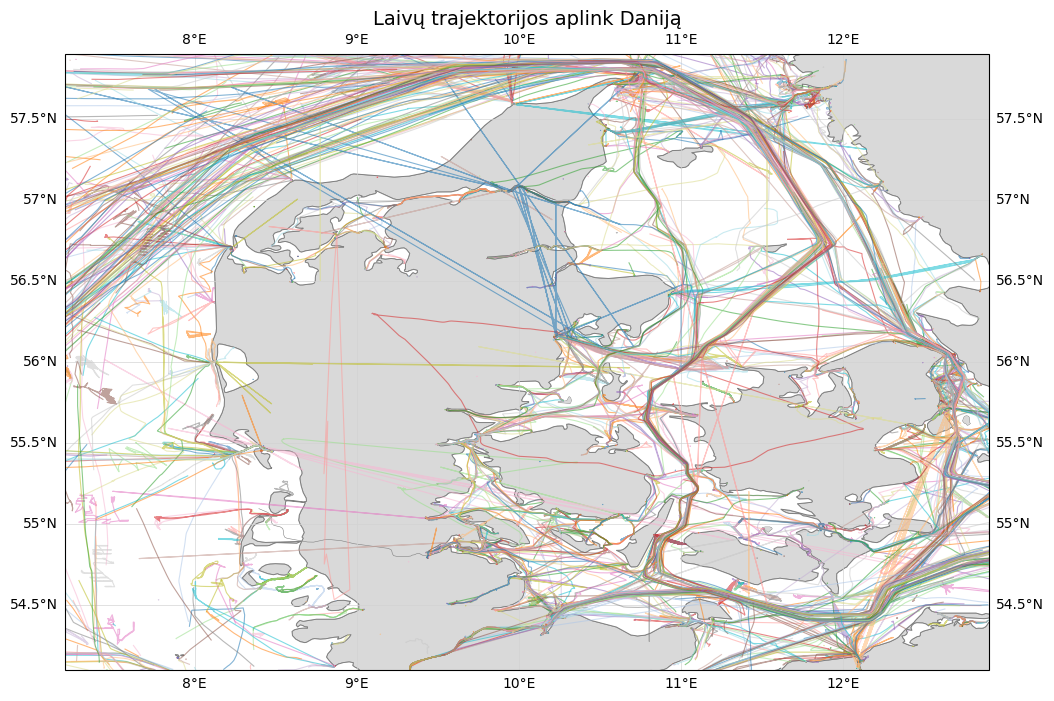

In [49]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# 1. Pasirenkam regioną aplink Daniją
lon_min, lon_max = 7.2, 12.9
lat_min, lat_max = 54.1, 57.9

# 2. Pasiliekam tik taškus tame regione
df_plot = df_ship_clean[
    df_ship_clean['longitude'].between(lon_min, lon_max) &
    df_ship_clean['latitude'].between(lat_min, lat_max)
].copy()

# 3. Dėl greičio galima praretinti taškus
#    Pvz. kas 5-as taškas kiekvienam laivui
# df_plot = (
#     df_plot
#     .sort_values(['mmsi', 'timestamp'])
#     .groupby('mmsi', group_keys=False)
#     .apply(lambda g: g.iloc[::5])
#     .reset_index(drop=True)
# )

# 4. Braižymas
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Fonas
ax.set_facecolor('#f2f2f2')
ax.add_feature(cfeature.LAND, facecolor='#d9d9d9', edgecolor='gray', linewidth=0.6, zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7, edgecolor='gray')
ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor='gray')

# Tinklelis ir geografinės etiketės
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.6,
    color='lightgray',
    alpha=0.8,
    linestyle='-'
)
gl.top_labels = True
gl.right_labels = True
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Spalvos trajektorijoms
cmap = plt.cm.tab20
mmsi_list = df_plot['mmsi'].drop_duplicates().tolist()

for i, mmsi in enumerate(mmsi_list):
    g = df_plot[df_plot['mmsi'] == mmsi]
    ax.plot(
        g['longitude'].values,
        g['latitude'].values,
        transform=ccrs.PlateCarree(),
        linewidth=0.8,
        alpha=0.55,
        color=cmap(i % 20)
    )

plt.title('Laivų trajektorijos aplink Daniją', fontsize=14)
plt.show()

In [25]:


def plot_ship_type_trajectories(
    df,
    ship_type,
    lon_min=7.2,
    lon_max=12.9,
    lat_min=54.1,
    lat_max=57.9,
    step=5,
    figsize=(12, 8),
    linewidth=0.7,
    alpha=0.4,
    title=None
):
    # 1. Filtras pagal laivo tipą
    df_type = df[df['ship_type'] == ship_type].copy()

    # 2. Filtras pagal regioną
    df_plot = df_type[
        df_type['longitude'].between(lon_min, lon_max) &
        df_type['latitude'].between(lat_min, lat_max)
    ].copy()

    # 3. Rikiavimas ir praretinimas
    # df_plot = (
    #     df_plot
    #     .sort_values(['mmsi', 'timestamp'])
    #     .groupby('mmsi', group_keys=False)
    #     .apply(lambda g: g.iloc[::step])
    #     .reset_index(drop=True)
    # )

    print(f"Laivo tipas: {ship_type}")
    print(f"Unikalių laivų: {df_plot['mmsi'].nunique()}")
    print(f"Bražomų taškų: {len(df_plot)}")

    # 4. Braižymas
    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    ax.set_facecolor('#f2f2f2')
    ax.add_feature(cfeature.LAND, facecolor='#d9d9d9', edgecolor='gray', linewidth=0.6, zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, edgecolor='gray')
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor='gray')

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.6,
        color='lightgray',
        alpha=0.8,
        linestyle='-'
    )
    gl.top_labels = True
    gl.right_labels = True
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    for _, g in df_plot.groupby('mmsi'):
        ax.plot(
            g['longitude'].values,
            g['latitude'].values,
            transform=ccrs.PlateCarree(),
            linewidth=linewidth,
            alpha=alpha
        )

    if title is None:
        title = f'{ship_type} laivų trajektorijos'

    plt.title(title, fontsize=14)
    plt.show()

krovininiai

In [35]:
plot_ship_type_trajectories(df_ship_clean, 'Cargo')

KeyError: 'ship_type'

tankeriai

Laivo tipas: Tanker
Unikalių laivų: 169
Bražomų taškų: 578267


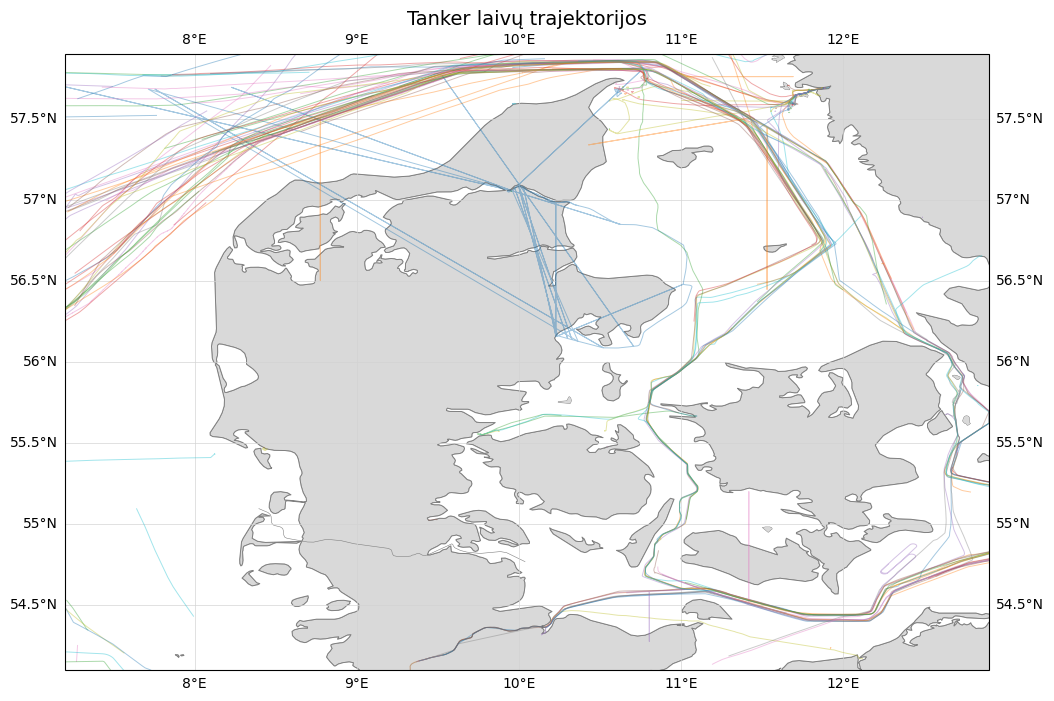

In [27]:
plot_ship_type_trajectories(df_ship_clean, 'Tanker')

In [28]:
numeric_cols = df_ship_clean.select_dtypes(include='number')
print(numeric_cols.corr(method='pearson'))

                   mmsi  latitude  longitude       rot       sog       cog  \
mmsi           1.000000  0.058430  -0.043142  0.000347  0.242180 -0.041448   
latitude       0.058430  1.000000  -0.145520  0.000094 -0.031576  0.059062   
longitude     -0.043142 -0.145520   1.000000 -0.001631  0.034243  0.000581   
rot            0.000347  0.000094  -0.001631  1.000000  0.000808  0.001109   
sog            0.242180 -0.031576   0.034243  0.000808  1.000000 -0.047533   
cog           -0.041448  0.059062   0.000581  0.001109 -0.047533  1.000000   
heading       -0.057155  0.057453   0.002329 -0.002331 -0.070621  0.531668   
width          0.488195 -0.048746  -0.092709  0.001469  0.483068 -0.059769   
length         0.519272 -0.042706  -0.052222  0.001496  0.567930 -0.064765   
draught        0.500915  0.024509  -0.104457  0.001302  0.379822 -0.016823   
a              0.592733 -0.012509  -0.018497  0.001199  0.449035 -0.061435   
b              0.139971 -0.057634  -0.062105  0.000964  0.401077

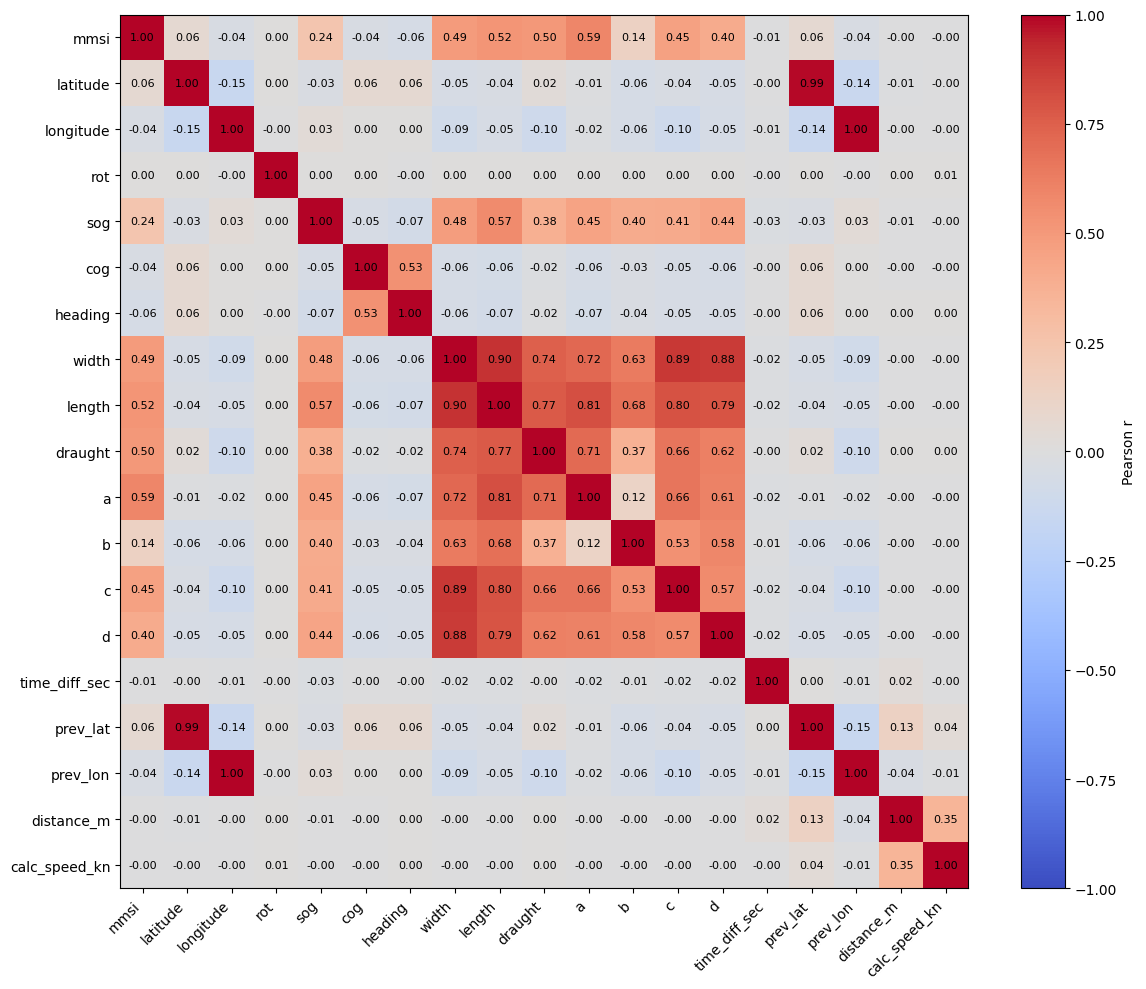

In [29]:
numeric_cols = df_ship_clean.select_dtypes(include="number")
corr_matrix = numeric_cols.corr(method="pearson")

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
plt.show()

In [45]:
df_ship_clean = df_ship_clean[['timestamp', 'mmsi', 'latitude', 'longitude']].copy()

In [48]:
# -----------------------------
# PARAMETERS
# -----------------------------
RESAMPLE_FREQ = '2min'
MAX_GAP = 1800  # seconds (30 min)

# -----------------------------
# 1. SORT DATA
# -----------------------------
df = df_ship_clean.sort_values(['mmsi', 'timestamp']).copy()

# -----------------------------
# 2. COMPUTE TIME GAPS
# -----------------------------
df['time_gap_sec'] = (
    df.groupby('mmsi')['timestamp']
    .diff()
    .dt.total_seconds()
)

# -----------------------------
# 3. CREATE SEGMENTS
# -----------------------------
df['segment_id'] = (
    (df['time_gap_sec'] > MAX_GAP)
    .groupby(df['mmsi'])
    .cumsum()
)

# -----------------------------
# 4. RESAMPLING FUNCTION
# -----------------------------
def resample_segment(group):
    mmsi = group.name[0]

    # ❗ FIX 1: skip tiny groups
    if len(group) < 2:
        return None

    group = (
        group.sort_values('timestamp')
        .drop_duplicates('timestamp')
        .set_index('timestamp')
    )

    # ❗ FIX 2: ensure valid time span
    if group.index.min() == group.index.max():
        return None

    grid = pd.date_range(
        start=group.index.min().ceil(RESAMPLE_FREQ),
        end=group.index.max().floor(RESAMPLE_FREQ),
        freq=RESAMPLE_FREQ
    )

    # ❗ FIX 3: empty grid
    if len(grid) == 0:
        return None

    tmp = group.reindex(group.index.union(grid)).sort_index()

    # ❗ FIX 4: safe interpolation
    try:
        tmp[['latitude', 'longitude']] = tmp[['latitude', 'longitude']].interpolate(
            method='time',
            limit=int(MAX_GAP / pd.to_timedelta(RESAMPLE_FREQ).total_seconds()),
            limit_area='inside'
        )
    except Exception:
        return None  # skip problematic segment

    tmp = tmp.loc[grid, ['latitude', 'longitude']].reset_index()
    tmp = tmp.rename(columns={'index': 'timestamp'})

    tmp['mmsi'] = mmsi

    return tmp[['timestamp', 'mmsi', 'latitude', 'longitude']]

# -----------------------------
# 5. APPLY
# -----------------------------
df_resampled = (
    df
    .groupby(['mmsi', 'segment_id'], group_keys=False)
    .apply(resample_segment)
    .dropna()
    .reset_index(drop=True)
)

# -----------------------------
# RESULT
# -----------------------------
df_resampled.head()

,timestamp,mmsi,latitude,longitude
0,2025-05-16 00:02:00,3638,55.332259,10.964870
1,2025-05-16 00:04:00,3638,55.332252,10.964874
2,2025-05-16 00:06:00,3638,55.332264,10.964853
3,2025-05-16 00:08:00,3638,55.332255,10.964862
4,2025-05-16 00:10:00,3638,55.332256,10.964865
